<a href="https://colab.research.google.com/github/Vidhi-Garg11/Financial-Stock-Prediction/blob/main/Financial_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance tensorflow scikit-learn matplotlib


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout


In [ ]:
TICKER = "JPM"          # JPMorgan Chase

WINDOW_SIZE = 90        # number of past days // 60 og
PRED_DAYS = 1           # days ahead to predict

CNN_FILTERS = 64
KERNEL_SIZE = 3

LSTM_UNITS = 50
DROPOUT_RATE = 0.2

EPOCHS = 20
BATCH_SIZE = 32


In [ ]:
# Cell 3 — REVERTED to original
df = yf.download(TICKER, start="2018-01-01")
df.columns = df.columns.get_level_values(0)  # keep this yfinance fix

features = df[["Open", "High", "Low", "Close", "Volume"]]

price_cols = ["Open", "High", "Low", "Close", "Volume"]
close_idx = price_cols.index("Close")   # = 3

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(features)

/tmp/ipython-input-1579445983.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Run this after Cell 3 to confirm Close is still column 3
print(list(features.columns))
# Should print: ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'EMA_20']
# Close = index 3 ✓

['Open', 'High', 'Low', 'Close', 'Volume']


In [ ]:
# Cell 4 — Predicted date
last_date = df.index[-1]
predicted_date = last_date + pd.tseries.offsets.BDay(PRED_DAYS)

In [ ]:
# Cell 5 — Build sequences
# FIX: must initialise X and y before appending
X, y = [], []

for i in range(WINDOW_SIZE, len(scaled_data) - PRED_DAYS):
    X.append(scaled_data[i - WINDOW_SIZE:i])
    y.append(scaled_data[i + PRED_DAYS, 3])   # index 3 = Close

X, y = np.array(X), np.array(y)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
# Cell 7 — Build model
n_features = scaled_data.shape[1]   # 5

model = Sequential()
# model.add(Conv1D(128, 3, activation="relu", input_shape=(WINDOW_SIZE, n_features)))
# model.add(MaxPooling1D(2))

# model.add(LSTM(64, return_sequences=True))
# model.add(Dropout(0.3))

# model.add(LSTM(32))
# model.add(Dropout(0.3))

# model.add(Dense(1))
# In Cell 7, increase units
model.add(Conv1D(128, 3, activation="relu", input_shape=(WINDOW_SIZE, n_features)))
model.add(MaxPooling1D(2))

model.add(LSTM(128, return_sequences=True))  # was 64
model.add(Dropout(0.3))

model.add(LSTM(64))                          # was 32
model.add(Dropout(0.3))

model.add(Dense(1))
model.compile(optimizer="adam", loss="huber")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Cell 8 — Train with early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,   # was 5
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - loss: 0.0056 - val_loss: 0.0019
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 5.9377e-04 - val_loss: 0.0017
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 5.0428e-04 - val_loss: 0.0023
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 5.0185e-04 - val_loss: 8.9709e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 5.8014e-04 - val_loss: 8.5387e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 4.2636e-04 - val_loss: 8.2447e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 4.7286e-04 - val_loss: 0.0011
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 4.0731e-04 - val_loss: 0.0014
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 4.0644e-04 - val_loss: 0.0013
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 4.2866e-04 - val_loss: 0.0020
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 3.4121e-04 - val_loss: 0.0014
Epoch 12/

In [ ]:
# Cell 9 — Evaluate on test set
pred_scaled = model.predict(X_test)

# Only inverse-transform the 5 price columns (scaler doesn't know about indicators)
dummy = np.zeros((len(pred_scaled), len(price_cols)))       # shape (n, 5)
dummy[:, close_idx] = pred_scaled[:, 0]
predictions = scaler.inverse_transform(dummy)[:, close_idx]

dummy_actual = np.zeros((len(y_test), len(price_cols)))     # shape (n, 5)
dummy_actual[:, close_idx] = y_test
actual_prices = scaler.inverse_transform(dummy_actual)[:, close_idx]

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
# Cell 10 — Predict next single day
last_window = scaled_data[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, n_features)

next_price_scaled = model.predict(last_window)

# FIX: dummy must be (1, 5) — same shape scaler was fit on
dummy_next = np.zeros((1, len(price_cols)))
dummy_next[0, close_idx] = next_price_scaled[0, 0]
next_price = scaler.inverse_transform(dummy_next)[0, close_idx]

print(f"Predicted closing price for {TICKER} on {predicted_date.date()}: ${next_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted closing price for JPM on 2026-02-16: $311.93


In [ ]:
# Cell 11 — 7-day forecast
future_days = 7
future_prices_scaled = []

current_window = scaled_data[-WINDOW_SIZE:].copy()

for _ in range(future_days):
    input_window = current_window.reshape(1, WINDOW_SIZE, n_features)
    pred = model.predict(input_window)[0, 0]
    future_prices_scaled.append(pred)

    new_row = current_window[-1].copy()
    new_row[close_idx] = pred                          # use close_idx not 3
    current_window = np.vstack([current_window[1:], new_row])

# FIX: dummy must be (7, 5) — same shape scaler was fit on
dummy_future = np.zeros((future_days, len(price_cols)))
dummy_future[:, close_idx] = future_prices_scaled
future_prices = scaler.inverse_transform(dummy_future)[:, close_idx]

future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1), periods=future_days
)

future_df = pd.DataFrame({"Date": future_dates, "Predicted Close Price": future_prices})
print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
        Date  Predicted Close Price
0 2026-02-16             311.926516
1 2026-02-17             311.271275
2 2026-02-18             310.101504
3 2026-02-19             309.040379
4 2026-02-20             307.885500
5 2026-02-23             306.893813
6 2026-02-24             305.875053


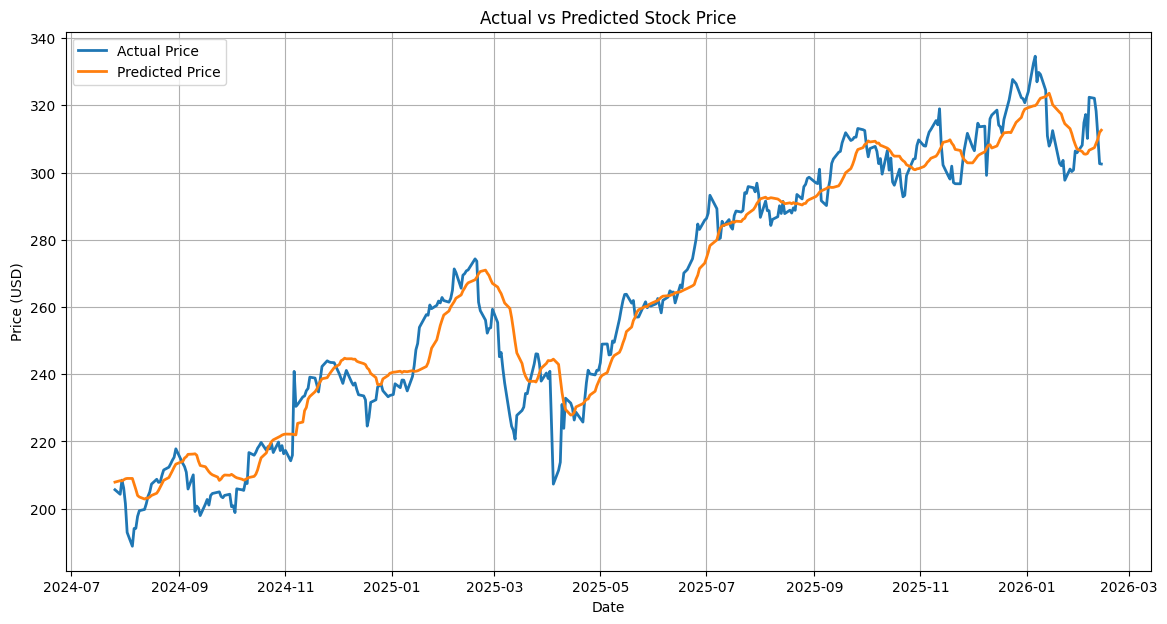

In [ ]:
# Cell 12 — Plot actual vs predicted
# FIX: add PRED_DAYS offset so dates align with what we predicted
test_dates = df.index[WINDOW_SIZE + PRED_DAYS + split :
                      WINDOW_SIZE + PRED_DAYS + split + len(predictions)]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, actual_prices, label="Actual Price", linewidth=2)
plt.plot(test_dates, predictions, label="Predicted Price", linewidth=2)
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 13 — Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(actual_prices, predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
mape = np.mean(np.abs((actual_prices - predictions) / actual_prices)) * 100  # ADD THIS

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")  # ADD THIS

MAE:  6.8204
RMSE: 8.8218
MAPE: 2.67%


In [ ]:
# errors = actual_prices - predictions

# plt.figure(figsize=(14, 5))
# plt.plot(test_dates, errors, color="red", linewidth=1)
# plt.axhline(0, color="black", linestyle="--", linewidth=1)
# plt.fill_between(test_dates, errors, 0, alpha=0.3, color="red")
# plt.title("Prediction Error Over Time")
# plt.xlabel("Date")
# plt.ylabel("Error (USD)")
# plt.grid(True)
# plt.show()

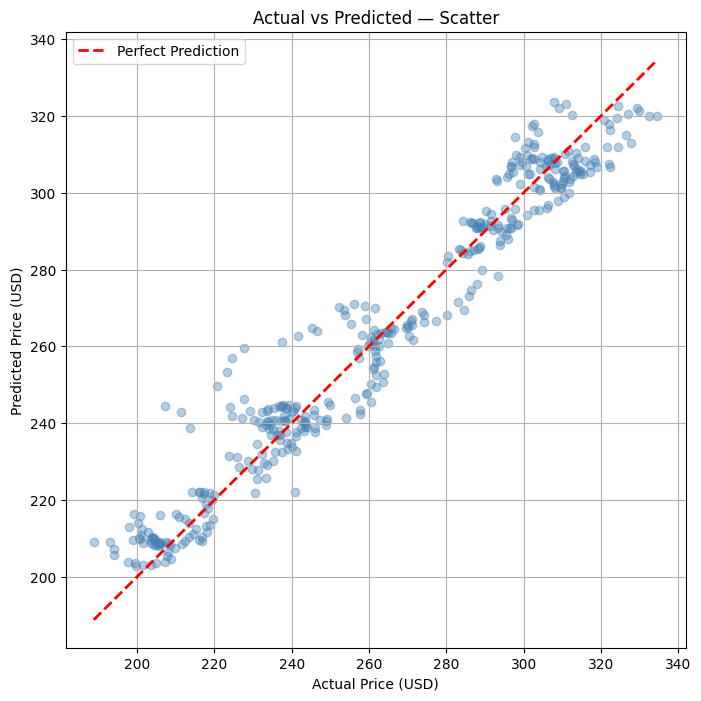

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(actual_prices, predictions, alpha=0.4, color="steelblue")
plt.plot([actual_prices.min(), actual_prices.max()],
         [actual_prices.min(), actual_prices.max()],
         color="red", linestyle="--", linewidth=2, label="Perfect Prediction")
plt.title("Actual vs Predicted — Scatter")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

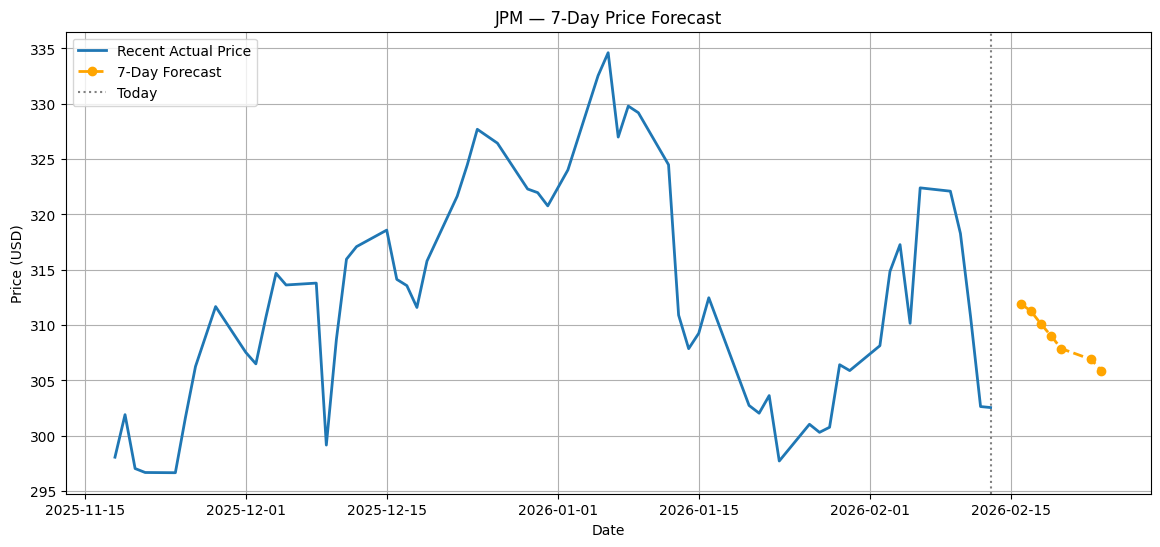

In [ ]:
# Last 60 days of actual + 7 day forecast
last_60_dates = df.index[-60:]
last_60_prices = df["Close"].values[-60:]

plt.figure(figsize=(14, 6))
plt.plot(last_60_dates, last_60_prices, label="Recent Actual Price", linewidth=2)
plt.plot(future_df["Date"], future_df["Predicted Close Price"],
         label="7-Day Forecast", linewidth=2, linestyle="--",
         color="orange", marker="o")
plt.axvline(df.index[-1], color="gray", linestyle=":", linewidth=1.5, label="Today")
plt.title(f"{TICKER} — 7-Day Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()